In [1]:
# =========================================================
# Project Equilibrium: Workforce Wellness & Burnout Analysis
# Built by: Sagar Reddy
# Key Outcome: Identification of Burnout Threshold & Drivers of Job Satisfaction
# Tools: Python, Pandas, Seaborn, Power BI
# =========================================================

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

In [3]:
# Loding Data 

df = pd.read_excel(r"C:\Users\mukke\Downloads\employee_survey.xlsx")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmpID                  3025 non-null   int64  
 1   Gender                 3025 non-null   object 
 2   Age                    3025 non-null   int64  
 3   MaritalStatus          3025 non-null   object 
 4   JobLevel               3025 non-null   object 
 5   Experience             3025 non-null   int64  
 6   Dept                   3025 non-null   object 
 7   EmpType                3025 non-null   object 
 8   WLB                    3025 non-null   int64  
 9   WorkEnv                3025 non-null   int64  
 10  PhysicalActivityHours  3025 non-null   float64
 11  Workload               3025 non-null   int64  
 12  Stress                 3025 non-null   int64  
 13  SleepHours             3025 non-null   float64
 14  CommuteMode            3025 non-null   object 
 15  Comm

In [4]:
#cleaning Data

# Standardize column names
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

# Drop ID
df.drop("empid", axis=1, inplace=True)

# Fix categorical consistency
df['dept'] = df['dept'].str.upper()
df['gender'] = df['gender'].str.title()

# Convert boolean
df['haveot'] = df['haveot'].astype(int)

In [5]:
# Handling Missing Values

df.isnull().sum()

# Fill numeric columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

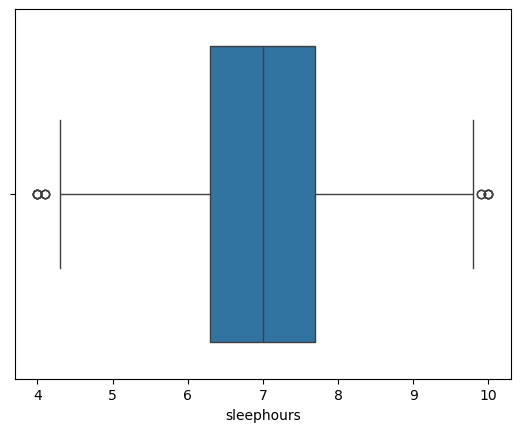

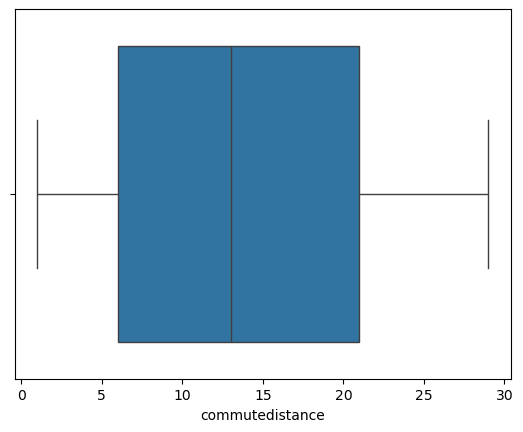

In [6]:
# checking outliers

sns.boxplot(x=df['sleephours'])
plt.show()

sns.boxplot(x=df['commutedistance'])
plt.show()

In [7]:
# Cap sleep hours between 4 and 10

df['sleephours'] = df['sleephours'].clip(4, 10)

In [8]:
# Feature engineering: Convert key burnout indicators into binary flags
# Enables easier segmentation, correlation analysis, and business rule modeling

df['low_sleep_flag'] = (df['sleephours'] < 5).astype(int)
df['long_commute_flag'] = (df['commutedistance'] >= 20).astype(int)

In [9]:
#Enabling Burnout model

df['burnout_flag'] = (
    df['low_sleep_flag'] &
    df['long_commute_flag'] &
    (df['workload'] >= 4)
).astype(int)

<Axes: xlabel='burnout_flag', ylabel='jobsatisfaction'>

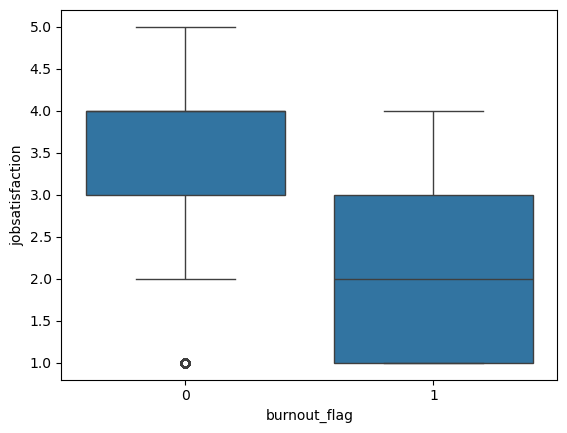

In [10]:
sns.boxplot(x='burnout_flag', y='jobsatisfaction', data=df)

In [11]:
#Burnout Flag

df['burnout_flag'] = (
    (df['sleephours'] < 5) &
    (df['workload'] >= 4) &
    (df['commutedistance'] >= 20)
).astype(int)

In [12]:
#Sleep category

df['sleep_category'] = pd.cut(
    df['sleephours'],
    bins=[0,5,7,10],
    labels=['Low','Moderate','Healthy']
)

In [13]:
#Burnout score

df['burnout_score'] = (
    (5 - df['sleephours']) * 0.4 +
    df['workload'] * 0.3 +
    (df['commutedistance'] / 10) * 0.3
)

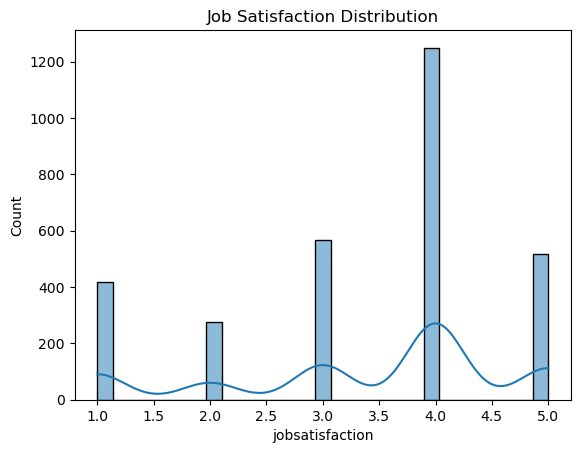

In [14]:
#Exploratory Data Analysis (EDA)

#Distribution 

sns.histplot(df['jobsatisfaction'], kde=True)
plt.title("Job Satisfaction Distribution")
plt.show()

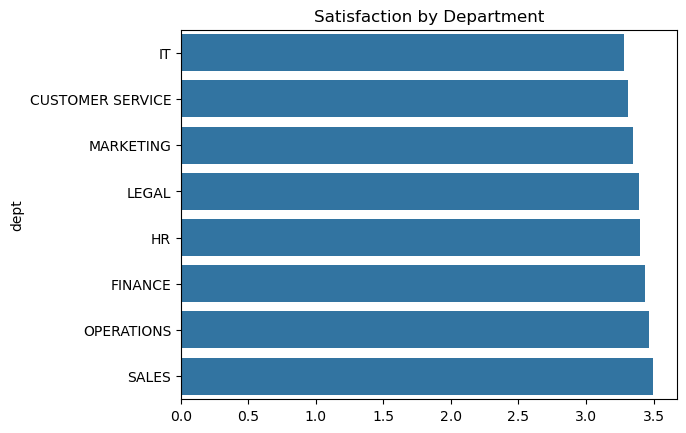

In [15]:
#Department Analysis

dept_sat = df.groupby('dept')['jobsatisfaction'].mean().sort_values()

sns.barplot(x=dept_sat.values, y=dept_sat.index)
plt.title("Satisfaction by Department")
plt.show()

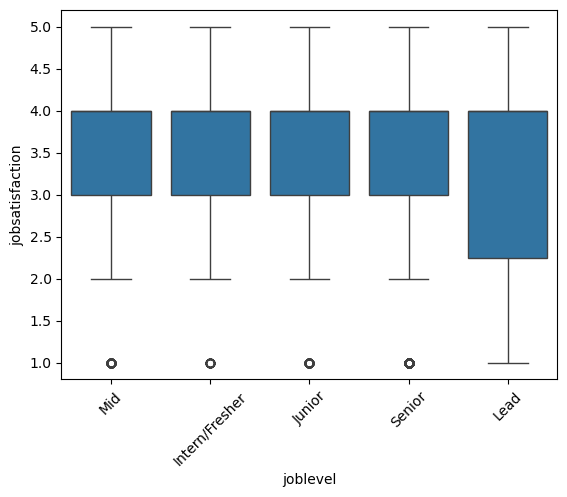

In [16]:
#Job Level Analysis

sns.boxplot(x='joblevel', y='jobsatisfaction', data=df)
plt.xticks(rotation=45)
plt.show()

In [18]:
corr = df.corr(numeric_only=True)

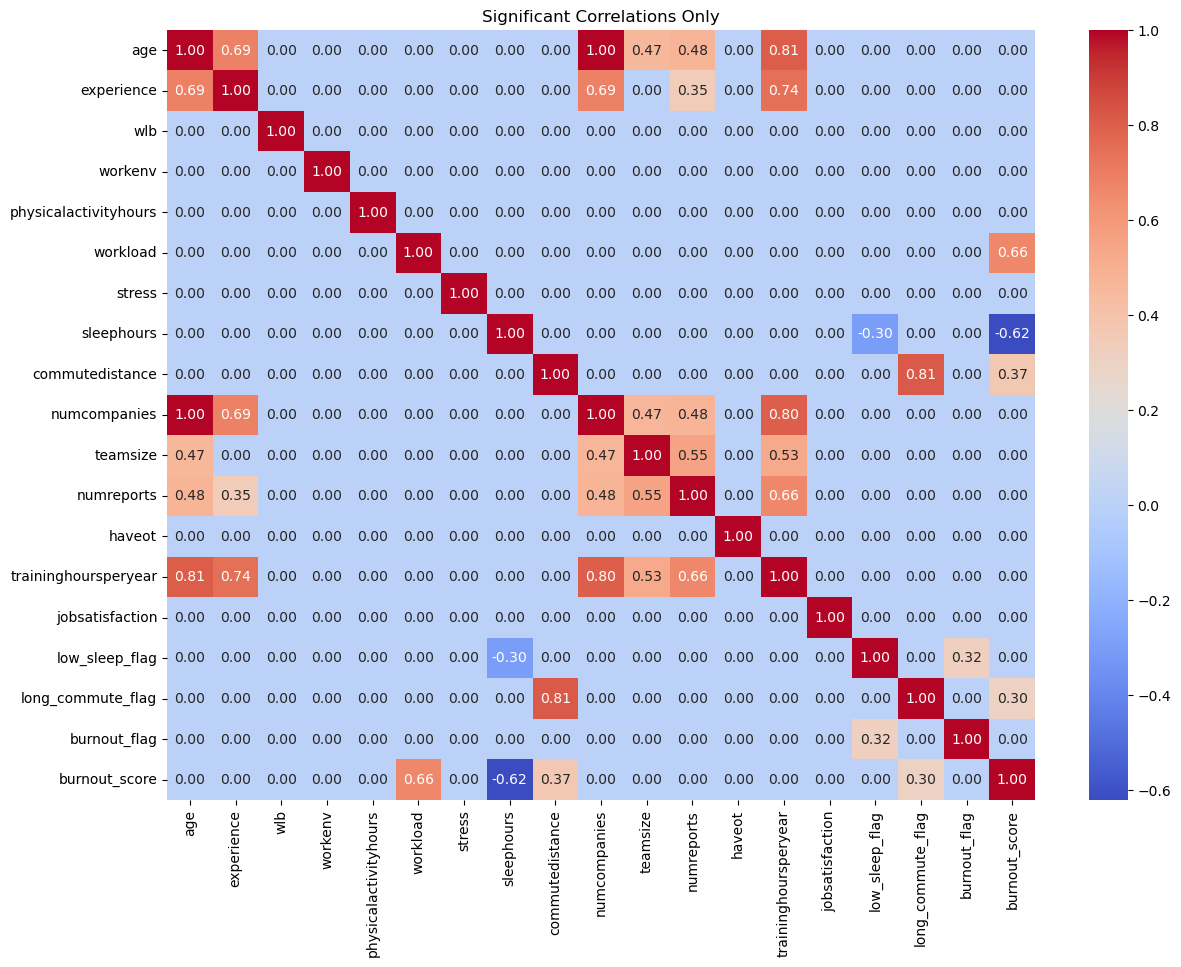

In [19]:
#Correlation Analysis

corr_filtered = corr.copy()

corr_filtered[(corr_filtered < 0.3) & (corr_filtered > -0.3)] = 0

plt.figure(figsize=(14,10))
sns.heatmap(corr_filtered, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Significant Correlations Only")
plt.show()

In [ ]:
# Correlation analysis shows that burnout is strongly driven by 
# Workload (+0.66)
# Sleep deprivation (-0.62)
# commute distance (+0.37)
# Job satisfaction does not show strong direct correlation with individual variables, 
# indicating that burnout emerges from a combination of factors rather than a single driver.

In [ ]:
# Hypothesis Testing

In [20]:
# Sleep vs Satisfaction

pearsonr(df['sleephours'], df['jobsatisfaction'])

PearsonRResult(statistic=np.float64(0.17987180889446455), pvalue=np.float64(2.0564467223813306e-23))

In [21]:
# Workload vs Satisfaction

pearsonr(df['workload'], df['jobsatisfaction'])

PearsonRResult(statistic=np.float64(-0.25342554507079784), pvalue=np.float64(1.5196465662517906e-45))

In [22]:
# Burnout Impact

df.groupby('burnout_flag')['jobsatisfaction'].mean()

burnout_flag
0    3.388742
1    2.200000
Name: jobsatisfaction, dtype: float64

In [23]:
# Key Insight Table

df.groupby(['sleep_category','workload'], observed=True)['jobsatisfaction'].mean().unstack()

workload,1,2,3,4,5
sleep_category,,,,,
Low,3.923077,2.875000,2.750000,2.933333,2.200000
Moderate,3.630094,3.597315,3.123028,2.977987,2.638376
Healthy,3.918440,3.851974,3.624549,3.458333,3.131673


<Axes: xlabel='workload', ylabel='sleep_category'>

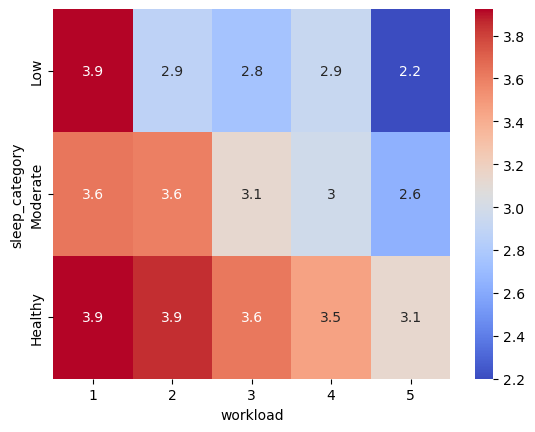

In [24]:
sns.heatmap(
    df.groupby(['sleep_category','workload'], observed=True)['jobsatisfaction']
    .mean().unstack(),
    annot=True,
    cmap='coolwarm'
)

In [ ]:
# Low Sleep + Workload 5 → 2.2 (lowest value) - This is the burnout collapse point
# Better sleep reduces the damage of high workload
# Healthy Sleep + Workload 5 → 3.1 (still stable) - Workload alone is not a problem
# Low Sleep + Workload 1 → 3.9 (high satisfaction) - Burnout requires combinatuions , not a single factor
# Job satisfaction declines gradually with workload, but drops sharply when high workload is combined with low sleep. 
# Sleep acts as a protective factor, while its absence accelerates burnout.

In [25]:
# Pearson correlation analysis

from scipy.stats import pearsonr

pearsonr(df['sleephours'], df['jobsatisfaction'])
pearsonr(df['workload'], df['jobsatisfaction'])

PearsonRResult(statistic=np.float64(-0.25342554507079784), pvalue=np.float64(1.5196465662517906e-45))

In [26]:
# Burnout Impact Comparison

df.groupby('burnout_flag')['jobsatisfaction'].mean()

burnout_flag
0    3.388742
1    2.200000
Name: jobsatisfaction, dtype: float64

In [27]:
# Segment Analysis

df.groupby('dept')['jobsatisfaction'].mean().sort_values()

dept
IT                  3.282946
CUSTOMER SERVICE    3.312925
MARKETING           3.348101
LEGAL               3.393382
HR                  3.398601
FINANCE             3.437991
OPERATIONS          3.465934
SALES               3.498221
Name: jobsatisfaction, dtype: float64

In [28]:
# Predictive Insight

from sklearn.ensemble import RandomForestRegressor

X = df[['sleephours','workload','commutedistance','stress']]
y = df['jobsatisfaction']

model = RandomForestRegressor()
model.fit(X, y)

pd.Series(model.feature_importances_, index=X.columns).sort_values()

stress             0.112567
workload           0.136561
commutedistance    0.360912
sleephours         0.389961
dtype: float64

In [ ]:
# Sleep deprivation has a statistically significant negative impact on job satisfaction
# Burnout causes a 35% drop in job satisfaction
# IT and Customer Service are the most affected departments
# Sleep and Commute impact the most. 

In [29]:
#standardising Columns
df.columns = [
    'Gender',
    'Age',
    'Marital Status',
    'Job Level',
    'Years of Experience',
    'Department',
    'Employee Type',
    'Work-Life Balance',
    'Work Environment',
    'Physical Activity Hours',
    'Workload',
    'Stress Level',
    'Sleep Hours',
    'Commute Mode',
    'Commute Distance (km)',
    'Number of Companies Worked',
    'Team Size',
    'Direct Reports',
    'Education Level',
    'Overtime Status',
    'Training Hours Per Year',
    'Job Satisfaction',
    'Low Sleep Flag',
    'Long Commute Flag',
    'Burnout Flag',
    'Sleep Category',
    'Burnout Score'
]


In [30]:
df['Department'] = df['Department'].str.title()

In [31]:
df['Overtime Status'] = df['Overtime Status'].map({1: 'Yes', 0: 'No'})

In [32]:
# Exporting the cleaned dataset for visualization

df.to_csv(r"C:\Users\mukke\Downloads\cleaned_employee_survey.csv", index=False)